# 01 - Analise Exploratoria (EDA)

**FarmTech Solutions / Fase 4 CAP 1**

Objetivo: entender a base que alimenta o modelo de regressao. Os dados vem da
tabela-fato `leituras_sensor` do backend ativo (Oracle FIAP ou SQLite; ver
`src/db.py`), unida ao nome da cultura.
O alvo e `produtividade_kg_ha`.

In [1]:
import sys
from pathlib import Path
DATA_DIR = Path.cwd().parent / 'data'
if str(DATA_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_DIR))
import feature_engineering as fe

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = fe.carregar_dados()
print('Linhas:', len(df), '| Culturas:', df['cultura'].nunique())
df.head()

Linhas: 2200 | Culturas: 22


,temperatura,umidade,ph,luminosity,n,p,k,chuva_mm,cultura,produtividade_kg_ha
0,22.75,90.69,5.52,50052.8,24.0,128.0,196.0,110.43,apple,3206.61
1,23.85,94.35,6.13,50365.6,7.0,144.0,197.0,114.05,apple,3715.90
2,22.61,94.59,6.23,47043.5,14.0,128.0,205.0,116.04,apple,3418.84
3,21.19,91.13,6.32,41251.9,8.0,120.0,201.0,122.23,apple,3330.04
4,23.41,91.70,5.59,38174.1,20.0,129.0,201.0,116.08,apple,3674.11


## Estatistica descritiva

In [2]:
df.describe().round(2)

,temperatura,umidade,ph,luminosity,n,p,k,chuva_mm,produtividade_kg_ha
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,25.62,71.48,6.47,45057.15,50.55,53.36,48.15,103.46,3348.44
std,5.06,22.26,0.77,14818.30,36.92,32.99,50.65,54.96,1035.06
min,8.83,14.26,3.50,0.00,0.00,5.00,5.00,20.21,1612.10
25%,22.77,60.26,5.97,35275.88,21.00,28.00,20.00,64.55,2605.03
50%,25.60,80.47,6.42,45277.05,37.00,51.00,32.00,94.86,3242.84
75%,28.56,89.95,6.92,54708.80,84.25,68.00,49.00,124.27,3904.98
max,43.68,99.98,9.94,96510.30,140.00,145.00,205.00,298.56,7558.01


## Distribuicao do alvo (produtividade_kg_ha)

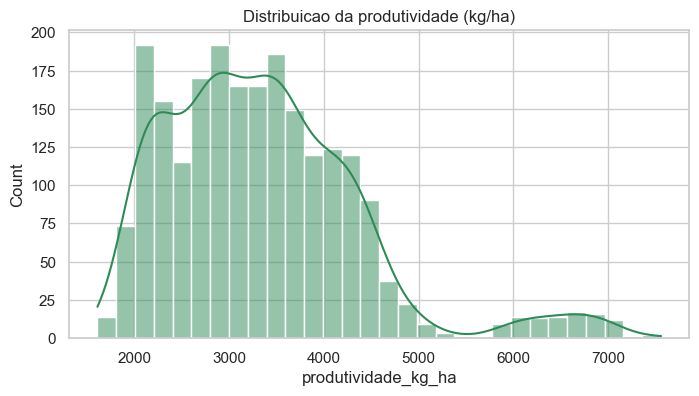

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['produtividade_kg_ha'], kde=True, ax=ax, color='seagreen')
ax.set_title('Distribuicao da produtividade (kg/ha)')
ax.set_xlabel('produtividade_kg_ha')
plt.show()

## Correlacao entre variaveis numericas

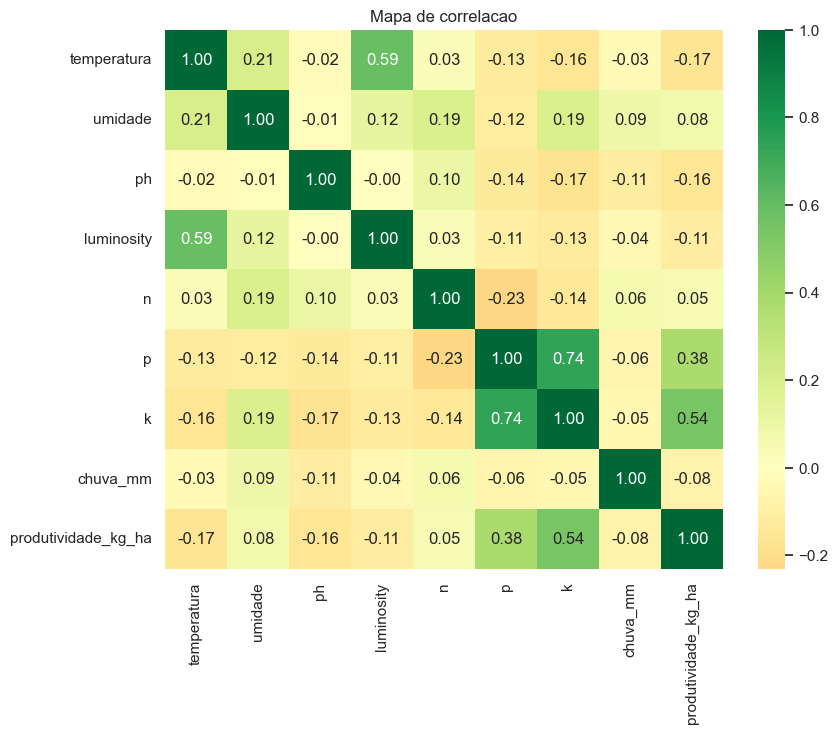

In [4]:
num = df[fe.NUMERIC_FEATURES + [fe.TARGET]]
corr = num.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Mapa de correlacao')
plt.show()

## Produtividade por cultura

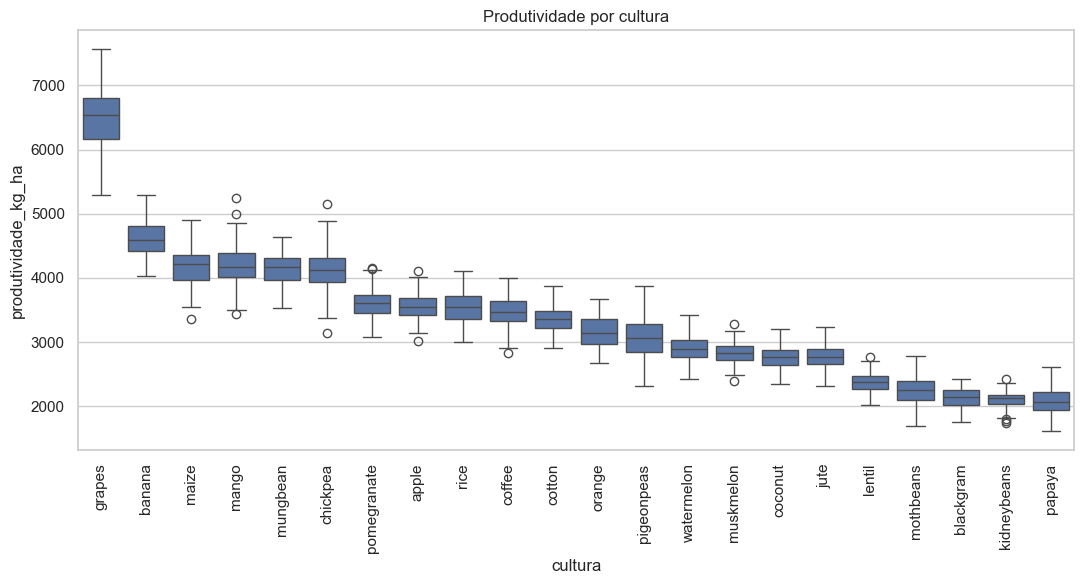

In [5]:
ordem = (df.groupby('cultura')['produtividade_kg_ha']
           .median().sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df, x='cultura', y='produtividade_kg_ha', order=ordem, ax=ax)
ax.set_title('Produtividade por cultura')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Relacao das variaveis-chave com o alvo

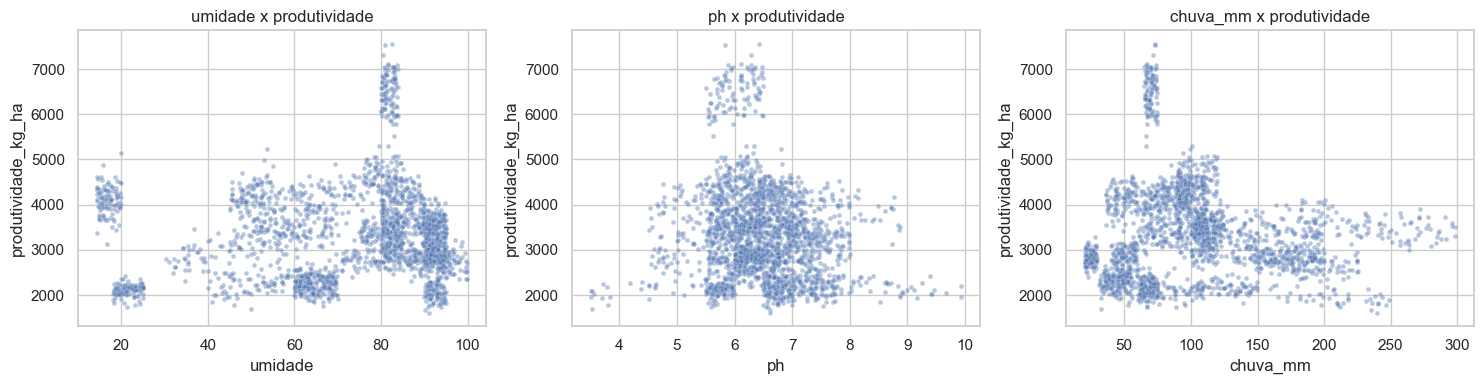

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, ['umidade', 'ph', 'chuva_mm']):
    sns.scatterplot(data=df, x=var, y='produtividade_kg_ha', s=12,
                    alpha=0.4, ax=ax)
    ax.set_title(f'{var} x produtividade')
plt.tight_layout()
plt.show()

## Conclusoes

- A produtividade varia bastante entre culturas (patamares distintos), o que
  reforca a cultura como feature relevante.
- Umidade, pH e chuva mostram relacao nao-linear com o alvo (faixas otimas),
  coerente com o desenho agronomico do dataset.
- Nenhuma feature isolada explica o alvo sozinha: o modelo precisa combinar
  variaveis. Justifica testar modelos lineares e nao-lineares no proximo passo.